# QELM vs QK

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import myQMLlib as myQML
import time
# Magic command to autoreload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)

In [3]:
print(rho_training.shape)
print(rho_training)
print('\n')
print(rho_training[0])

(100, 2, 2)
[[[ 0.45832473+0.j          0.08794504+0.4075993j ]
  [ 0.08794504-0.4075993j   0.54167527+0.j        ]]

 [[ 0.7286615 +0.j          0.07630965-0.42418463j]
  [ 0.07630965+0.42418463j  0.2713385 +0.j        ]]

 [[ 0.85010981+0.j          0.15331963+0.21017187j]
  [ 0.15331963-0.21017187j  0.14989019+0.j        ]]

 [[ 0.29301894+0.j          0.38757099-0.10256412j]
  [ 0.38757099+0.10256412j  0.70698106+0.j        ]]

 [[ 0.37693925+0.j         -0.21689544-0.32211117j]
  [-0.21689544+0.32211117j  0.62306075+0.j        ]]

 [[ 0.37134787+0.j         -0.45476293+0.01752176j]
  [-0.45476293-0.01752176j  0.62865213+0.j        ]]

 [[ 0.65257743+0.j         -0.23734369+0.15225674j]
  [-0.23734369-0.15225674j  0.34742257+0.j        ]]

 [[ 0.89681633+0.j          0.0975929 -0.03107029j]
  [ 0.0975929 +0.03107029j  0.10318367+0.j        ]]

 [[ 0.16835469+0.j          0.00369962-0.17143156j]
  [ 0.00369962+0.17143156j  0.83164531+0.j        ]]

 [[ 0.52743968+0.j          0.3332

In [4]:
rho = myQML.generate_random_density_matrix(2)
print(rho)
print(np.trace(rho))

[[ 0.79678109-3.78407474e-19j -0.32913151+2.26906409e-01j]
 [-0.32913151-2.26906409e-01j  0.20321891+3.78407474e-19j]]
(0.9999999999999999-2.8888949165808538e-34j)


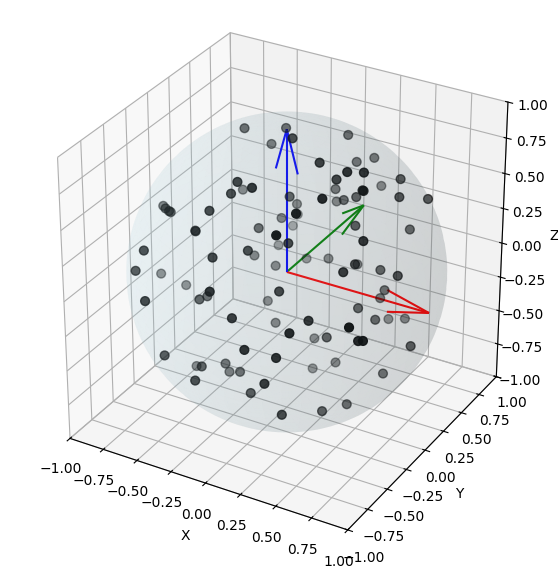

In [5]:
bloch_points_1 = [myQML.density_to_bloch(rho) for rho in rho_training]
myQML.plot_bloch_sphere(bloch_points_1)

In [12]:

kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

Computing Gram matrix of size 100x100...
[[0.55434205+0.j 0.43952966+0.j 0.47554971+0.j ... 0.53385263+0.j
  0.39971166+0.j 0.48795457+0.j]
 [0.43952966+0.j 0.58379249+0.j 0.48422487+0.j ... 0.45790677+0.j
  0.54962122+0.j 0.46409345+0.j]
 [0.47554971+0.j 0.48422487+0.j 0.62322393+0.j ... 0.48763349+0.j
  0.70421466+0.j 0.63043041+0.j]
 ...
 [0.53385263+0.j 0.45790677+0.j 0.48763349+0.j ... 0.79866732+0.j
  0.52860599+0.j 0.61498919+0.j]
 [0.39971166+0.j 0.54962122+0.j 0.70421466+0.j ... 0.52860599+0.j
  0.93790421+0.j 0.73686037+0.j]
 [0.48795457+0.j 0.46409345+0.j 0.63043041+0.j ... 0.61498919+0.j
  0.73686037+0.j 0.69321435+0.j]]
[-5.97544570e-15 -1.86252480e-15 -1.09452889e-15 -1.03701801e-15
 -9.39876317e-16 -8.88233666e-16 -8.62349310e-16 -8.24202032e-16
 -7.69343814e-16 -7.59052183e-16 -7.44448294e-16 -7.03888132e-16
 -6.57282064e-16 -6.22173036e-16 -6.06970192e-16 -5.98837921e-16
 -5.87037762e-16 -5.80078976e-16 -5.57358000e-16 -5.18869369e-16
 -4.89050969e-16 -4.42814263e-16 -

In [7]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=1e-5)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)

Predictions on test data (first 5):
[-0.03538972  0.48062065 -0.01695627 -0.23145569 -0.34514775]
Original test labels (first 5):
[-0.03538977  0.48062116 -0.01695635 -0.23145594 -0.34514814]
Mean Squared Error on training data: 0.0000
Computing kernel matrix for 100 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(100,)

Predictions on training data (first 5):
[ 0.17588984  0.15261921  0.30663891  0.77514117 -0.43379035]
Original training labels (first 5):
[ 0.17589008  0.15261929  0.30663925  0.77514199 -0.43379088]


In [8]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
    kernelmodel.fit(rho_training, expe_training_X)
    predictions = kernelmodel.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)
Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)
Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complet

In [9]:
print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

Mean Squared Error across realizations: 10269.527463420518


In [10]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel_le = myQML.QuantumKernelRegression2(regularization_lambda=1e-6, num_shots=1000)
    
    kernelmodel_le.fit(rho_training, expe_training_X, "le")
    predictions = kernelmodel_le.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

  Completed realization 10/50 | Current MSE: 0.008377
  Completed realization 20/50 | Current MSE: 0.000862
  Completed realization 30/50 | Current MSE: 0.001230
  Completed realization 40/50 | Current MSE: 0.002176
  Completed realization 50/50 | Current MSE: 0.001216
Mean Squared Error across realizations: 0.1123544727862541


In [11]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel_swap = myQML.QuantumKernelRegression2(regularization_lambda=1e-6, num_shots=1000)
    kernelmodel_swap.fit(rho_training, expe_training_X, "le")
    predictions = kernelmodel_le.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

  Completed realization 10/50 | Current MSE: 0.001237
  Completed realization 20/50 | Current MSE: 0.001070
  Completed realization 30/50 | Current MSE: 0.001132
  Completed realization 40/50 | Current MSE: 0.001196
  Completed realization 50/50 | Current MSE: 0.001246
Mean Squared Error across realizations: 0.001163477516934941


Starting Learning Curve Experiment (Shots = None)

Evaluating N_train = 10...
  -> LE Mean MSE:   0.0057 ± 0.0024
  -> SWAP Mean MSE: 0.0129 ± 0.0047
  -> Time taken:    4.6 seconds

Evaluating N_train = 100...
  -> LE Mean MSE:   0.0000 ± 0.0000
  -> SWAP Mean MSE: 0.0001 ± 0.0000
  -> Time taken:    23.3 seconds

Evaluating N_train = 1000...
  -> LE Mean MSE:   0.0000 ± 0.0000
  -> SWAP Mean MSE: 0.0000 ± 0.0000
  -> Time taken:    541.5 seconds

Evaluating N_train = 5000...
  -> LE Mean MSE:   0.0000 ± 0.0000
  -> SWAP Mean MSE: 0.0000 ± 0.0000
  -> Time taken:    5109.4 seconds

Evaluating N_train = 10000...
  -> LE Mean MSE:   0.0000 ± 0.0000
  -> SWAP Mean MSE: 0.0000 ± 0.0000
  -> Time taken:    34159.1 seconds
Experiment finished in 663.97 minutes.


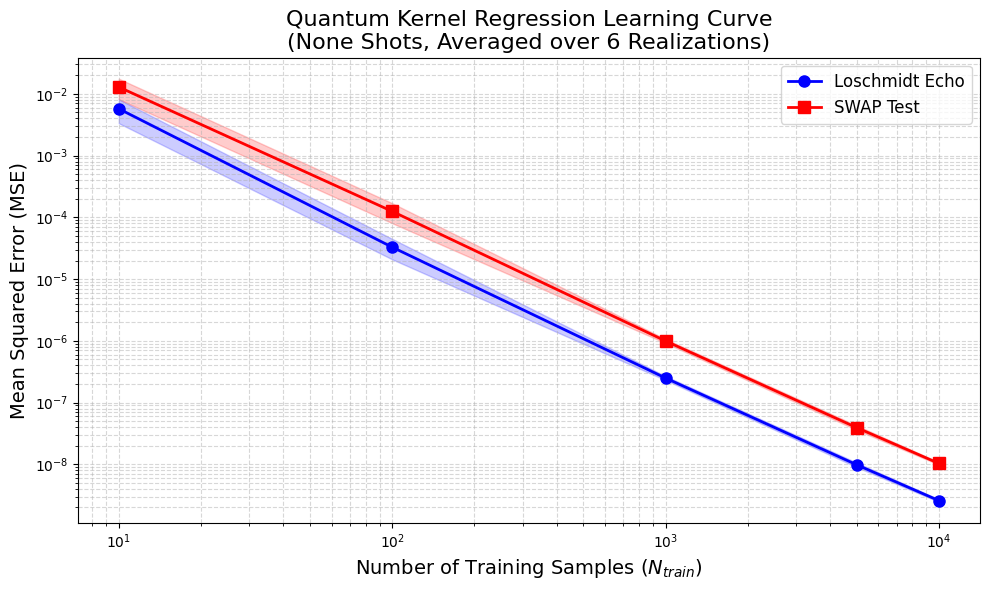

In [17]:

import matplotlib.pyplot as plt
import time

# --- 1. Dataset Generator ---
def generate_dataset(num_samples: int):
    """Generates 1-qubit states and Pauli-X expectation labels."""
    rhos = []
    labels = []
    sigma_x = np.array([[0, 1], [1, 0]])
    
    for _ in range(num_samples):
        rand_mat = np.random.rand(2, 2) + 1j * np.random.rand(2, 2)
        herm_mat = rand_mat + rand_mat.conj().T
        rho = (herm_mat @ herm_mat.conj().T)
        rho = rho / np.trace(rho)
        
        y = np.real(np.trace(rho @ sigma_x)) 
        rhos.append(rho)
        labels.append(y)
        
    return np.array(rhos), np.array(labels)

# --- 2. Experiment Setup ---
N_train_list = [10, 100, 1000, 5000, 10000]
N_test = 1000           # Keep test set size fixed to compare MSE fairly
num_shots = None       # Fixed finite statistics
num_realizations = 6  # Average over 20 runs

# Regularization must be relatively high due to 1000 shots of noise!
# If you get Singular Matrix errors at N=10000, increase this to 0.1 or 0.5.
reg_lambda = 0.05 

# Arrays to store results
le_means, le_stds = [], []
swap_means, swap_stds = [], []

print(f"Starting Learning Curve Experiment (Shots = {num_shots})")
print("="*60)

total_start_time = time.time()

# --- 3. Main Loop ---
for N_train in N_train_list:
    print(f"\nEvaluating N_train = {N_train}...")
    
    mse_le_current = []
    mse_swap_current = []
    
    step_start_time = time.time()
    
    for r in range(num_realizations):
        # 1. Generate EXACT SAME dataset for both models in this realization
        rho_train, y_train = generate_dataset(N_train)
        rho_test, y_test = generate_dataset(N_test)
        
        # 2. Loschmidt Echo Model
        model_le = myQML.QuantumKernelRegression2(regularization_lambda=reg_lambda, num_shots=num_shots)
        model_le.fit(rho_train, y_train, kernel_type="le")
        preds_le = model_le.predict(rho_test)
        mse_le_current.append(np.mean((preds_le - y_test)**2))
        
        # 3. SWAP Test Model
        model_swap = myQML.QuantumKernelRegression2(regularization_lambda=reg_lambda, num_shots=num_shots)
        model_swap.fit(rho_train, y_train, kernel_type="swap")
        preds_swap = model_swap.predict(rho_test)
        mse_swap_current.append(np.mean((preds_swap - y_test)**2))
        
        # Optional: Print progress for long runs (N=5000 and N=10000)
        if (r + 1) % 10 == 0 and N_train >= 1000:
            print(f"  Realization {r+1}/{num_realizations} done.")

    # Calculate statistics for this N_train
    le_means.append(np.mean(mse_le_current))
    le_stds.append(np.std(mse_le_current))
    
    swap_means.append(np.mean(mse_swap_current))
    swap_stds.append(np.std(mse_swap_current))
    
    step_time = time.time() - step_start_time
    print(f"  -> LE Mean MSE:   {le_means[-1]:.4f} ± {le_stds[-1]:.4f}")
    print(f"  -> SWAP Mean MSE: {swap_means[-1]:.4f} ± {swap_stds[-1]:.4f}")
    print(f"  -> Time taken:    {step_time:.1f} seconds")

print("="*60)
print(f"Experiment finished in {(time.time() - total_start_time)/60:.2f} minutes.")

# --- 4. Plotting ---
# Convert lists to numpy arrays for easier plotting math
N_train_arr = np.array(N_train_list)
le_means, le_stds = np.array(le_means), np.array(le_stds)
swap_means, swap_stds = np.array(swap_means), np.array(swap_stds)

plt.figure(figsize=(10, 6))

# Plot Loschmidt Echo
plt.plot(N_train_arr, le_means, label='Loschmidt Echo', marker='o', 
         color='blue', linewidth=2, markersize=8)
plt.fill_between(N_train_arr, le_means - le_stds, le_means + le_stds, 
                 color='blue', alpha=0.2)

# Plot SWAP Test
plt.plot(N_train_arr, swap_means, label='SWAP Test', marker='s', 
         color='red', linewidth=2, markersize=8)
plt.fill_between(N_train_arr, swap_means - swap_stds, swap_means + swap_stds, 
                 color='red', alpha=0.2)

# Formatting the plot
plt.xscale('log') # Log scale because N goes from 10 to 10000
plt.yscale('log') # Log scale for MSE is standard to see asymptotic behavior
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Quantum Kernel Regression Learning Curve\n({num_shots} Shots, Averaged over {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()

# Show and/or save the plot
# plt.savefig("learning_curve.png", dpi=300)
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\i'
<>:41: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_55454/2044585311.py:41: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {shots}" if shots is not None else "Exact ($s=\infty$)"


Training QELM Models...


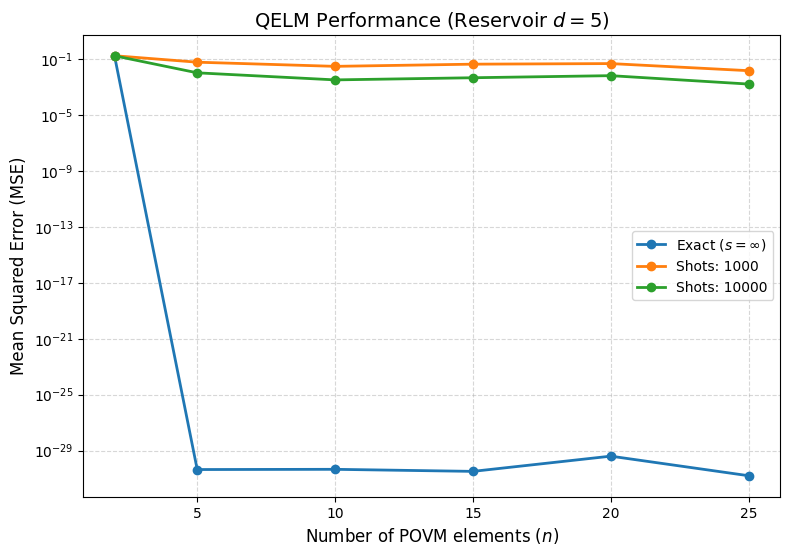

In [5]:
d_in = 2
d_reservoir = 5
d_out = d_in * d_reservoir # Output space of isometry must be 10

# Generate Isometry to embed 2D state into 10D state
V = myQML.random_isometry(d_in=d_in, d_out=d_out)

# We will test different sizes of POVMs acting on the d=5 reservoir
povm_sizes = [2, 5, 10, 15, 20, 25] 
povm_families_d5 = {n: myQML.generate_random_povm(dim=d_reservoir, num_elements=n) for n in povm_sizes}

# --- 3. Run Experiments (Exact vs Noisy) ---
shot_list = [None, 1000, 10000] # None = Exact
mse_results = {shots: [] for shots in shot_list}

print("Training QELM Models...")

for shots in shot_list:
    for n in povm_sizes:
        # 1. Initialize the QELM Model
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V,
            povm=povm_families_d5[n],
            bipartite_dims=(d_in, d_reservoir), # (2, 5)
            keep_subsystem=1,                   # Keep the d=5 reservoir, trace out the d=2
            num_shots=shots                     # Apply finite statistics
        )
        
        # 2. Train the Model
        qelm.fit(rho_training, expe_training_X)
        
        # 3. Predict and compute MSE
        predictions = qelm.predict(rho_test)
        mse = np.mean((predictions - expe_test_X)**2)
        mse_results[shots].append(mse)

# --- 4. Plot Results ---
plt.figure(figsize=(9, 6))

for shots in shot_list:
    label = f"Shots: {shots}" if shots is not None else "Exact ($s=\infty$)"
    plt.plot(povm_sizes, mse_results[shots], marker='o', linewidth=2, label=label)

plt.yscale('log')
plt.xlabel('Number of POVM elements ($n$)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('QELM Performance (Reservoir $d=5$)', fontsize=14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

Starting QELM Learning Curve Experiment (Shots = 1000)

Evaluating N_train = 10...
  -> Mean MSE: 0.0365 ± 0.0096
  -> Time:     7.1 seconds

Evaluating N_train = 20...
  -> Mean MSE: 0.0937 ± 0.0855
  -> Time:     8.2 seconds

Evaluating N_train = 30...
  -> Mean MSE: 0.0973 ± 0.0617
  -> Time:     8.0 seconds

Evaluating N_train = 50...
  -> Mean MSE: 0.0329 ± 0.0120
  -> Time:     7.5 seconds

Evaluating N_train = 100...
  -> Mean MSE: 0.0199 ± 0.0049
  -> Time:     5.9 seconds

Evaluating N_train = 500...
  -> Mean MSE: 0.0170 ± 0.0042
  -> Time:     13.3 seconds

Evaluating N_train = 1000...
  -> Mean MSE: 0.0156 ± 0.0040
  -> Time:     23.9 seconds

Evaluating N_train = 5000...
  -> Mean MSE: 0.0167 ± 0.0044
  -> Time:     131.3 seconds
Experiment finished in 3.42 minutes.


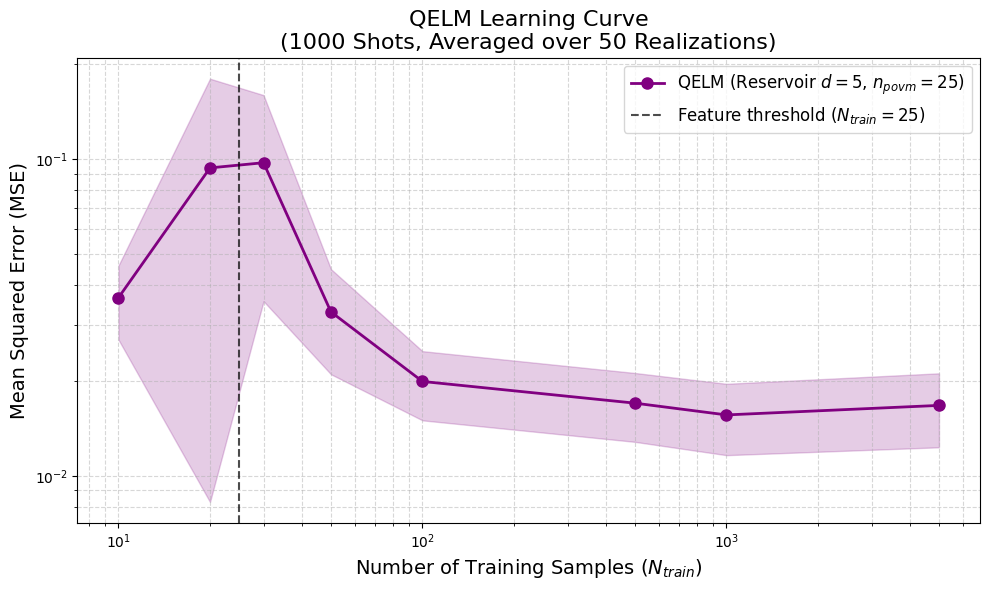

In [7]:
import time

# --- 1. Helper Functions (Ensure you have these from previous steps) ---
def generate_dataset(num_samples: int):
    rhos = []
    labels = []
    sigma_x = np.array([[0, 1], [1, 0]])
    for _ in range(num_samples):
        rand_mat = np.random.rand(2, 2) + 1j * np.random.rand(2, 2)
        herm_mat = rand_mat + rand_mat.conj().T
        rho = (herm_mat @ herm_mat.conj().T)
        rho = rho / np.trace(rho)
        y = np.real(np.trace(rho @ sigma_x)) 
        rhos.append(rho)
        labels.append(y)
    return np.array(rhos), np.array(labels)

# --- 2. Experiment Setup ---
# Notice we added values around 25 to see the "phase transition" 
# where N_train crosses the number of POVM features!
N_train_list = [10, 20, 30, 50, 100, 500, 1000, 5000]
N_test = 200
num_realizations = 50
num_shots = 1000  # 1000 shots of noise for realism

# Reservoir Physical Setup
d_in = 2
d_reservoir = 5
d_out = d_in * d_reservoir
num_povm_elements = 25  # An informationally complete POVM for d=5 is 5^2 = 25

qelm_means = []
qelm_stds = []

print(f"Starting QELM Learning Curve Experiment (Shots = {num_shots})")
print("="*60)

total_start_time = time.time()

# --- 3. Main Evaluation Loop ---
for N_train in N_train_list:
    print(f"\nEvaluating N_train = {N_train}...")
    mse_current = []
    step_start_time = time.time()
    
    for r in range(num_realizations):
        # 1. Generate random training and test states
        rho_train, y_train = generate_dataset(N_train)
        rho_test, y_test = generate_dataset(N_test)
        
        # 2. Generate a NEW random reservoir (Isometry and POVM) for each realization
        # This gives us the average performance over the ensemble of all possible random QELMs
        V = myQML.random_isometry(d_in=d_in, d_out=d_out)
        povm = myQML.generate_random_povm(dim=d_reservoir, num_elements=num_povm_elements)
        
        # 3. Initialize QELM Model
        model_qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V,
            povm=povm,
            bipartite_dims=(d_in, d_reservoir),
            keep_subsystem=1,
            num_shots=num_shots
        )
        
        # 4. Train and Predict
        model_qelm.fit(rho_train, y_train)
        preds = model_qelm.predict(rho_test)
        
        # 5. Compute MSE
        mse = np.mean((preds - y_test)**2)
        mse_current.append(mse)
        
    # Calculate statistics for this N_train
    qelm_means.append(np.mean(mse_current))
    qelm_stds.append(np.std(mse_current))
    
    step_time = time.time() - step_start_time
    print(f"  -> Mean MSE: {qelm_means[-1]:.4f} ± {qelm_stds[-1]:.4f}")
    print(f"  -> Time:     {step_time:.1f} seconds")

print("="*60)
print(f"Experiment finished in {(time.time() - total_start_time)/60:.2f} minutes.")

# --- 4. Plotting ---
N_train_arr = np.array(N_train_list)
qelm_means = np.array(qelm_means)
qelm_stds = np.array(qelm_stds)

plt.figure(figsize=(10, 6))

# Plot QELM curve with error bands
plt.plot(N_train_arr, qelm_means, label='QELM (Reservoir $d=5$, $n_{povm}=25$)', 
         marker='o', color='purple', linewidth=2, markersize=8)
plt.fill_between(N_train_arr, qelm_means - qelm_stds, qelm_means + qelm_stds, 
                 color='purple', alpha=0.2)

# Add a vertical line to show where N_train = num_povm_elements
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'Feature threshold ($N_{{train}} = {num_povm_elements}$)')

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM Learning Curve\n({num_shots} Shots, Averaged over {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Starting QML Showdown! (Shots = 1000, Realizations = 50)
Evaluating N_train = 10...
  -> QELM MSE: 0.0420
  -> K-LE MSE: 0.2715
  -> K-SW MSE: 0.0223
  -> Time:     10.8s
Evaluating N_train = 25...
  -> QELM MSE: 242.4078
  -> K-LE MSE: 48.3177
  -> K-SW MSE: 78.3616
  -> Time:     20.3s
Evaluating N_train = 50...
  -> QELM MSE: 0.0324
  -> K-LE MSE: 2.3314
  -> K-SW MSE: 0.4697
  -> Time:     39.4s
Evaluating N_train = 100...
  -> QELM MSE: 0.0207
  -> K-LE MSE: 0.1069
  -> K-SW MSE: 0.9030
  -> Time:     77.4s
Evaluating N_train = 250...
  -> QELM MSE: 0.0167
  -> K-LE MSE: 286.0897
  -> K-SW MSE: 11.8734
  -> Time:     305.8s
Evaluating N_train = 500...
  -> QELM MSE: 0.0163
  -> K-LE MSE: 0.8174
  -> K-SW MSE: 1.3156
  -> Time:     598.8s
Evaluating N_train = 600...
  -> QELM MSE: 0.0154
  -> K-LE MSE: 1.3518
  -> K-SW MSE: 380.9148
  -> Time:     814.2s
Experiment finished in 31.1 minutes.


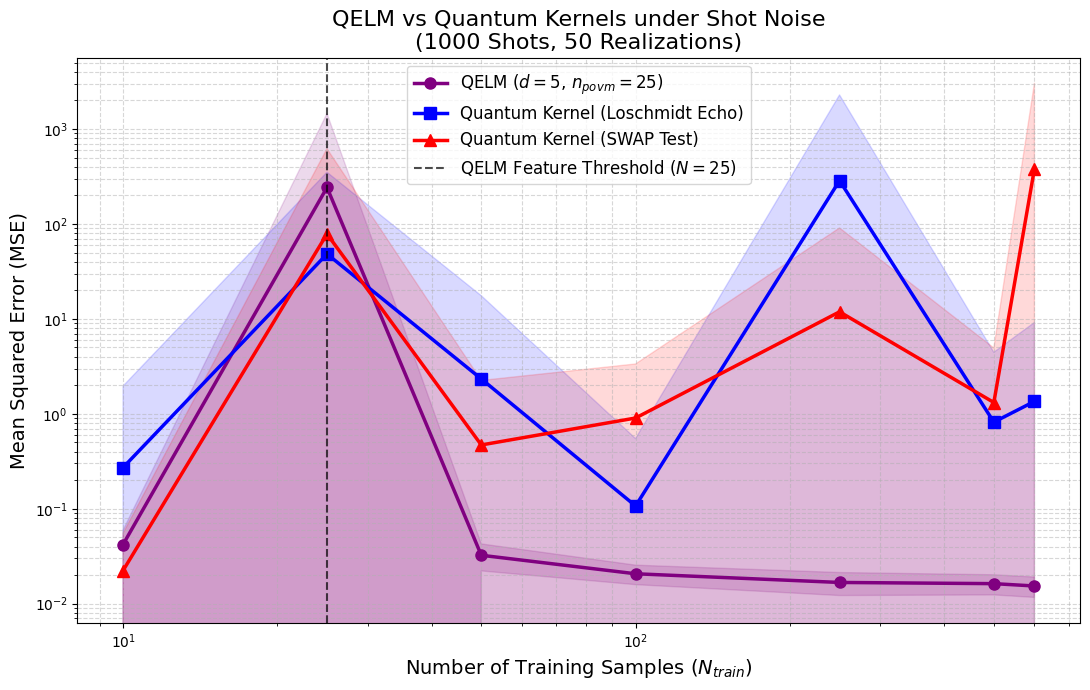

In [ ]:
def generate_dataset(num_samples: int):
    rhos = []
    labels = []
    sigma_x = np.array([[0, 1], [1, 0]])
    for _ in range(num_samples):
        rand_mat = np.random.rand(2, 2) + 1j * np.random.rand(2, 2)
        herm_mat = rand_mat + rand_mat.conj().T
        rho = (herm_mat @ herm_mat.conj().T)
        rho = rho / np.trace(rho)
        y = np.real(np.trace(rho @ sigma_x)) 
        rhos.append(rho)
        labels.append(y)
    return np.array(rhos), np.array(labels)

# ==========================================
# 3. EXPERIMENT CONFIGURATION
# ==========================================
N_train_list = [10, 25, 50, 100, 250, 500, 600, 800] # Added 25 to catch QELM singularity
N_test = 200
num_realizations = 50
num_shots = 1000

# Kernel Config
reg_lambda = 0.05

# QELM Config
d_in, d_reservoir = 2, 5
num_povm_elements = 25 

# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)
total_time = time.time()

# ==========================================
# 4. MAIN LOOP
# ==========================================
for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()
    
    for r in range(num_realizations):
        # 1. Generate one dataset used identically by all 3 models
        rho_train, y_train = generate_dataset(N_train)
        rho_test, y_test = generate_dataset(N_test)
        
        # --- Train & Eval QELM ---
        V = myQML.random_isometry(d_in=d_in, d_out=d_in*d_reservoir)
        povm = myQML.generate_random_povm(dim=d_reservoir, num_elements=num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_reservoir), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))

        # --- Train & Eval Kernel Loschmidt Echo ---
        kle = myQML.QuantumKernelRegression2(reg_lambda, num_shots)
        kle.fit(rho_train, y_train, kernel_type="le")
        mse_runs['Kernel_LE'].append(np.mean((kle.predict(rho_test) - y_test)**2))
        
        # --- Train & Eval Kernel SWAP Test ---
        kswap = myQML.QuantumKernelRegression2(reg_lambda, num_shots)
        kswap.fit(rho_train, y_train, kernel_type="swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kswap.predict(rho_test) - y_test)**2))

    # Save means and stds
    for model in results.keys():
        results[model].append(np.mean(mse_runs[model]))
        stds[model].append(np.std(mse_runs[model]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# 5. PLOTTING
# ==========================================
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=5$, $n_{povm}=25$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# Add feature threshold line for QELM
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'QELM Feature Threshold ($N = {num_povm_elements}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Starting QML Showdown! (Shots = 10000, Realizations = 50)
Evaluating N_train = 10...
  -> QELM MSE: 0.0066
  -> K-LE MSE: 0.0030
  -> K-SW MSE: 0.0079
  -> Time:     7.3s
Evaluating N_train = 25...
  -> QELM MSE: 9.2955
  -> K-LE MSE: 0.0005
  -> K-SW MSE: 0.0017
  -> Time:     19.8s
Evaluating N_train = 50...
  -> QELM MSE: 0.0053
  -> K-LE MSE: 0.1807
  -> K-SW MSE: 0.0005
  -> Time:     44.9s
Evaluating N_train = 100...
  -> QELM MSE: 0.0034
  -> K-LE MSE: 0.0461
  -> K-SW MSE: 0.4342
  -> Time:     58.6s
Evaluating N_train = 250...
  -> QELM MSE: 0.0031
  -> K-LE MSE: 0.1100
  -> K-SW MSE: 0.0558
  -> Time:     197.7s
Evaluating N_train = 500...
  -> QELM MSE: 0.0027
  -> K-LE MSE: 773.2358
  -> K-SW MSE: 0.8857
  -> Time:     666.2s
Evaluating N_train = 600...
  -> QELM MSE: 0.0028
  -> K-LE MSE: 0.1364
  -> K-SW MSE: 0.1296
  -> Time:     979.2s
Evaluating N_train = 800...
  -> QELM MSE: 0.0027
  -> K-LE MSE: 0.1933
  -> K-SW MSE: 0.0260
  -> Time:     1369.5s
Experiment finished

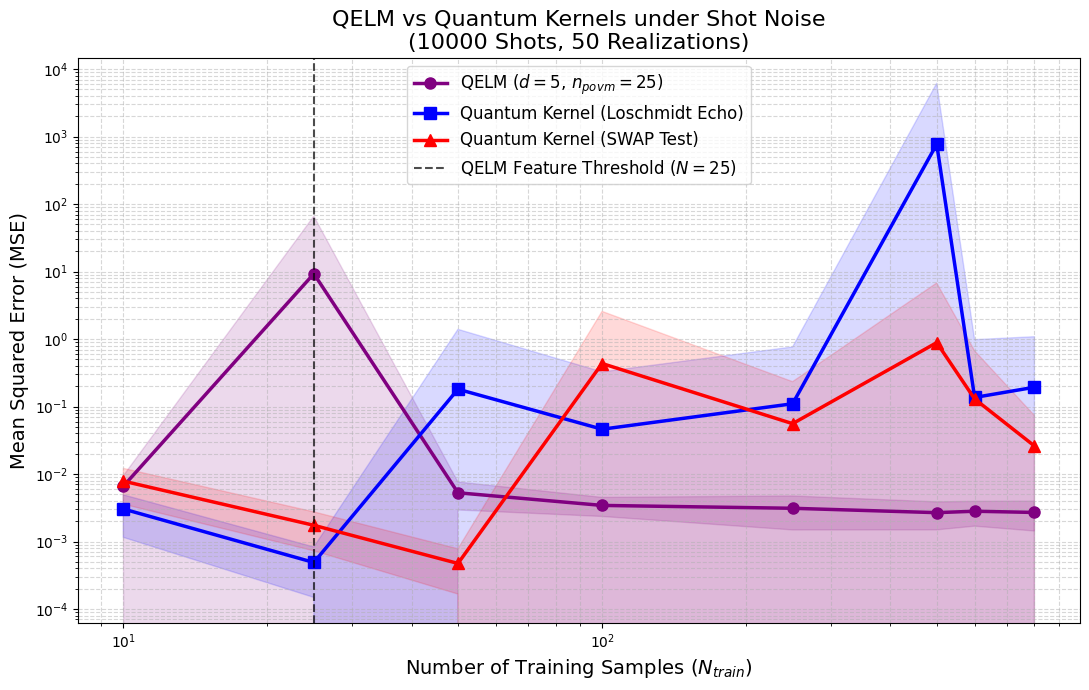

In [7]:
def generate_dataset(num_samples: int):
    rhos = []
    labels = []
    sigma_x = np.array([[0, 1], [1, 0]])
    for _ in range(num_samples):
        rand_mat = np.random.rand(2, 2) + 1j * np.random.rand(2, 2)
        herm_mat = rand_mat + rand_mat.conj().T
        rho = (herm_mat @ herm_mat.conj().T)
        rho = rho / np.trace(rho)
        y = np.real(np.trace(rho @ sigma_x)) 
        rhos.append(rho)
        labels.append(y)
    return np.array(rhos), np.array(labels)

# ==========================================
# 3. EXPERIMENT CONFIGURATION
# ==========================================
N_train_list = [10, 25, 50, 100, 250, 500, 600, 800] # Added 25 to catch QELM singularity
N_test = 200
num_realizations = 50
num_shots = 10000

# Kernel Config
reg_lambda = 0.05

# QELM Config
d_in, d_reservoir = 2, 5
num_povm_elements = 25 

# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"Starting QML Showdown! (Shots = {num_shots}, Realizations = {num_realizations})")
print("="*70)
total_time = time.time()

# ==========================================
# 4. MAIN LOOP
# ==========================================
for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()
    
    for r in range(num_realizations):
        # 1. Generate one dataset used identically by all 3 models
        rho_train, y_train = generate_dataset(N_train)
        rho_test, y_test = generate_dataset(N_test)
        
        # --- Train & Eval QELM ---
        V = myQML.random_isometry(d_in=d_in, d_out=d_in*d_reservoir)
        povm = myQML.generate_random_povm(dim=d_reservoir, num_elements=num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_reservoir), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))

        # --- Train & Eval Kernel Loschmidt Echo ---
        kle = myQML.QuantumKernelRegression2(reg_lambda, num_shots)
        kle.fit(rho_train, y_train, kernel_type="le")
        mse_runs['Kernel_LE'].append(np.mean((kle.predict(rho_test) - y_test)**2))
        
        # --- Train & Eval Kernel SWAP Test ---
        kswap = myQML.QuantumKernelRegression2(reg_lambda, num_shots)
        kswap.fit(rho_train, y_train, kernel_type="swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kswap.predict(rho_test) - y_test)**2))

    # Save means and stds
    for model in results.keys():
        results[model].append(np.mean(mse_runs[model]))
        stds[model].append(np.std(mse_runs[model]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# 5. PLOTTING
# ==========================================
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=5$, $n_{povm}=25$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# Add feature threshold line for QELM
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'QELM Feature Threshold ($N = {num_povm_elements}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Starting QML Showdown! (Shots = None, Realizations = 10)
Evaluating N_train = 10...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     3.8s
Evaluating N_train = 25...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     5.1s
Evaluating N_train = 50...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     8.3s
Experiment finished in 0.3 minutes.


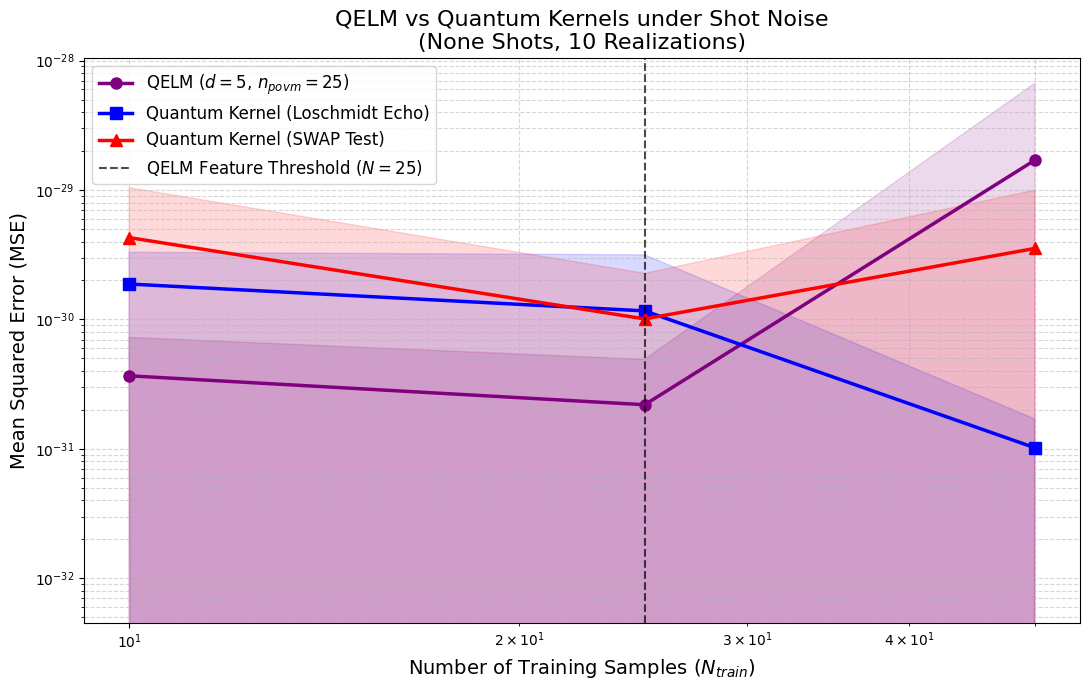

In [14]:
def generate_dataset(num_samples: int):
    rhos = []
    labels = []
    sigma_x = np.array([[0, 1], [1, 0]])
    for _ in range(num_samples):
        rand_mat = np.random.rand(2, 2) + 1j * np.random.rand(2, 2)
        herm_mat = rand_mat + rand_mat.conj().T
        rho = (herm_mat @ herm_mat.conj().T)
        rho = rho / np.trace(rho)
        y = np.real(np.trace(rho @ sigma_x)) 
        rhos.append(rho)
        labels.append(y)
    return np.array(rhos), np.array(labels)

# ==========================================
# 3. EXPERIMENT CONFIGURATION
# ==========================================
N_train_list = [10, 25, 50] # Added 25 to catch QELM singularity
N_test = 200
num_realizations = 10
num_shots = None

# Kernel Config
reg_lambda = 0

# QELM Config
d_in, d_reservoir = 2, 5
num_povm_elements = 25 

# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"Starting QML Showdown! (Shots = {num_shots}, Realizations = {num_realizations})")
print("="*70)
total_time = time.time()

# ==========================================
# 4. MAIN LOOP
# ==========================================
for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()
    
    for r in range(num_realizations):
        # 1. Generate one dataset used identically by all 3 models
        rho_train, y_train = generate_dataset(N_train)
        rho_test, y_test = generate_dataset(N_test)
        
        # --- Train & Eval QELM ---
        V = myQML.random_isometry(d_in=d_in, d_out=d_in*d_reservoir)
        povm = myQML.generate_random_povm(dim=d_reservoir, num_elements=num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_reservoir), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))

        # --- Train & Eval Kernel Loschmidt Echo ---
        kle = myQML.QuantumKernelRegression2(reg_lambda, num_shots)
        kle.fit(rho_train, y_train, kernel_type="le")
        mse_runs['Kernel_LE'].append(np.mean((kle.predict(rho_test) - y_test)**2))
        
        # --- Train & Eval Kernel SWAP Test ---
        kswap = myQML.QuantumKernelRegression2(reg_lambda, num_shots)
        kswap.fit(rho_train, y_train, kernel_type="swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kswap.predict(rho_test) - y_test)**2))

    # Save means and stds
    for model in results.keys():
        results[model].append(np.mean(mse_runs[model]))
        stds[model].append(np.std(mse_runs[model]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# 5. PLOTTING
# ==========================================
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=5$, $n_{povm}=25$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# Add feature threshold line for QELM
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'QELM Feature Threshold ($N = {num_povm_elements}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
print(kle.gram_matrix())

AttributeError: 'QuantumKernelRegression2' object has no attribute 'gram_matrix'